# Fixture context — fixture difficulty (`fdr_avg`) and `total_points`
_Read-only: how fixture difficulty changes the target — whether fixture-chasing is justified, how big the effect is, and through which channel, by position._

**Sections:** (a) total_points by FDR tier · (b) blank & return rate by FDR tier

---

## Setup
> Whole season, `minutes > 0`; bin `fdr_avg` into easy / medium / hard difficulty tiers.

**FDR meaning:** `fdr_avg` is the gameweek's average fixture difficulty rating (1.0–5.0; 1 = easiest, 5 = hardest); a DGW row averages its two fixtures, hence half-steps. SGW and DGW rows are pooled here (mild DGW inflation where they land); the dedicated SGW-vs-DGW treatment is `fixture_doubling.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.distribution import (
    compute_distribution_stats,
    compare_cohorts,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

# Descriptive characterisation uses the WHOLE season: GW 1 to the latest
# completed GW. No early-GW lower bound (that was a predictive-evaluation
# choice in the older EDA-1 record, not relevant here).
STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

# Analytical population: PARTICIPATION filter, not a performance gate.
# Available players who actually featured -> minutes > 0. `minutes` can be NULL
# for some rows; minutes > 0 naturally excludes NULLs. The 60-minute
# performance boundary is NOT imposed here -- deferred to the exposure/ layer.
mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["fdr_avg"].notna()].copy()  # FDR tier analysis needs a rating

POSITIONS = ["GK", "DEF", "MID", "FWD"]

# FDR tiers as OPERATIONAL HEURISTICS (not derived cut-points):
#   easy   : fdr_avg <= 2          (1 = easiest)
#   medium : 2 < fdr_avg < 4
#   hard   : fdr_avg >= 4          (5 = hardest)
TIER_ORDER = ["easy", "medium", "hard"]

def fdr_tier(v):
    if v <= 2:
        return "easy"
    if v >= 4:
        return "hard"
    return "medium"

df["fdr_tier"] = df["fdr_avg"].map(fdr_tier)
df["fdr_tier"] = pd.Categorical(df["fdr_tier"], categories=TIER_ORDER, ordered=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0 (participation, not a performance gate), with fdr_avg present, n = {len(df):,}")
print("\nFDR tiers (operational heuristics):  easy = fdr_avg <= 2 | medium = 2 < fdr_avg < 4 | hard = fdr_avg >= 4")
print("Tier counts:")
for tier in TIER_ORDER:
    print(f"  {tier:<7}: {int((df['fdr_tier'] == tier).sum()):>6,}")

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0 (participation, not a performance gate), with fdr_avg present, n = 11,361

FDR tiers (operational heuristics):  easy = fdr_avg <= 2 | medium = 2 < fdr_avg < 4 | hard = fdr_avg >= 4
Tier counts:
  easy   :  1,971
  medium :  6,879
  hard   :  2,511


## (a) `total_points` distribution by FDR tier and position
> Do players score more against easy fixtures than hard ones, and how big is the gap by position?

The `total_points` distribution across the three FDR tiers within each position via `compare_cohorts` (cutoffs `easy <= 2`, `2 < medium < 4`, `hard >= 4` are stated heuristics). The easy-minus-hard gap sizes the fixture-chasing payoff — but it is descriptive association, not causal: easy-fixture rows skew toward stronger teams, so part of any gap is team quality.

In [2]:
tier_rows = []
for pos in POSITIONS:
    sub = df[df.position == pos]
    cohorts = {tier: sub[sub["fdr_tier"] == tier] for tier in TIER_ORDER}
    stats = compare_cohorts(cohorts, value_col="total_points")
    for tier in TIER_ORDER:
        s = stats.loc[tier]
        tier_rows.append({
            "position": pos,
            "fdr_tier": tier,
            "n": int(s["count"]) if not np.isnan(s["count"]) else 0,
            "mean": s["mean"],
            "median": s["median"],
            "std": s["std"],
            "p90": s["p90"],
        })
fdr_by_pos = pd.DataFrame(tier_rows)
display(fdr_by_pos.round(2))

# Easy-minus-hard mean gap per position -- the headline fixture-chasing number.
gap_rows = []
for pos in POSITIONS:
    p = fdr_by_pos[fdr_by_pos.position == pos].set_index("fdr_tier")
    gap_rows.append({
        "position": pos,
        "mean_easy": p.loc["easy", "mean"],
        "mean_hard": p.loc["hard", "mean"],
        "easy_minus_hard": round(p.loc["easy", "mean"] - p.loc["hard", "mean"], 2),
    })
fdr_gap = pd.DataFrame(gap_rows)
display(fdr_gap.round(2))

,position,fdr_tier,n,mean,median,std,p90
0,GK,easy,129,4.270,3.000,3.010,8.000
1,GK,medium,460,3.350,2.000,2.700,7.000
2,GK,hard,168,2.810,2.000,2.530,7.000
3,DEF,easy,673,3.940,2.000,3.600,9.000
4,DEF,medium,2369,3.070,2.000,3.140,8.000
5,DEF,hard,862,2.450,1.000,2.720,6.000
6,MID,easy,913,3.290,2.000,3.230,8.000
7,MID,medium,3193,3.010,2.000,2.930,7.000
8,MID,hard,1182,2.500,2.000,2.390,5.000
9,FWD,easy,256,3.400,2.000,3.630,9.000


,position,mean_easy,mean_hard,easy_minus_hard
0,GK,4.270,2.810,1.460
1,DEF,3.940,2.450,1.490
2,MID,3.290,2.500,0.790
3,FWD,3.400,2.490,0.910


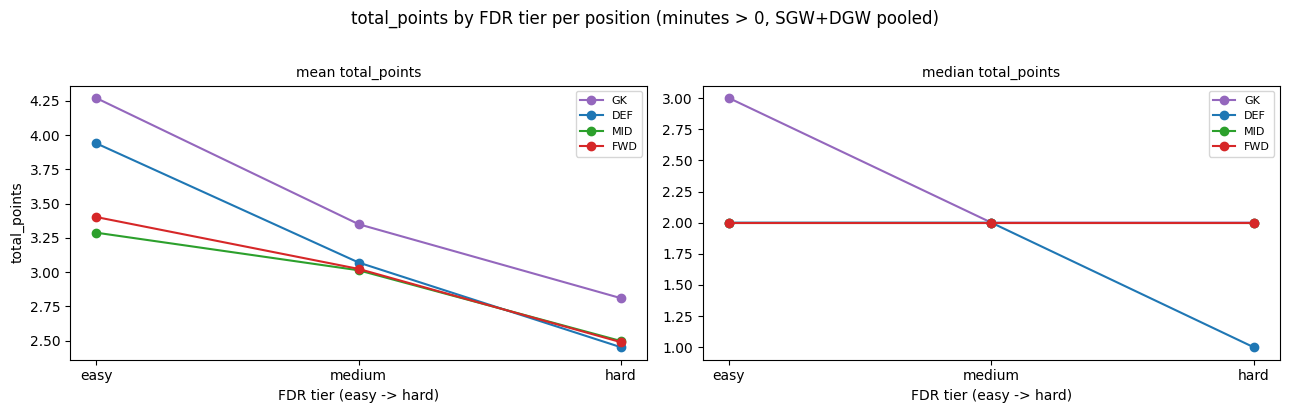

In [3]:
# Mean and median Y by tier per position reveal the gradient a table flattens:
# a downward slope easy -> hard is the fixture effect, position by position.
colours = {"GK": "#9467bd", "DEF": "#1f77b4", "MID": "#2ca02c", "FWD": "#d62728"}
x = np.arange(len(TIER_ORDER))
fig, (ax_mean, ax_med) = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for pos in POSITIONS:
    sub = fdr_by_pos[fdr_by_pos.position == pos].set_index("fdr_tier").reindex(TIER_ORDER)
    ax_mean.plot(x, sub["mean"].to_numpy(dtype=float), "-o", color=colours[pos], label=pos)
    ax_med.plot(x, sub["median"].to_numpy(dtype=float), "-o", color=colours[pos], label=pos)
for ax, title in [(ax_mean, "mean total_points"), (ax_med, "median total_points")]:
    ax.set_xticks(x)
    ax.set_xticklabels(TIER_ORDER)
    ax.set_xlabel("FDR tier (easy -> hard)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
ax_mean.set_ylabel("total_points")
fig.suptitle("total_points by FDR tier per position (minutes > 0, SGW+DGW pooled)", y=1.02)
plt.tight_layout()
plt.show()

## (b) Blank rate and return rate by FDR tier and position
> Does easy-fixture scoring show up as fewer blanks, more returns, or both — and does the channel differ by position?

Within each (position, FDR tier) cell, the share that blank (`= 0`) and the share that return (`>= 4`). This decomposes the mean gap from (a) into mechanism — floor (fewer blanks) vs ceiling (more returns) — over the participation population (cameos included), with the same team-quality confound.

In [4]:
fdr_rates = (
    df.groupby(["position", "fdr_tier"])["total_points"]
    .apply(lambda y: pd.Series({
        "n": len(y),
        "blank_rate_%": round((y == 0).mean() * 100, 1) if len(y) else float("nan"),
        "return_4+_%": round((y >= 4).mean() * 100, 1) if len(y) else float("nan"),
    }))
    .reset_index()
)
display(fdr_rates)


,position,fdr_tier,level_2,total_points
0,DEF,easy,n,673.000
1,DEF,easy,blank_rate_%,4.600
2,DEF,easy,return_4+_%,45.800
3,DEF,medium,n,2369.000
4,DEF,medium,blank_rate_%,7.800
5,DEF,medium,return_4+_%,31.800
6,DEF,hard,n,862.000
7,DEF,hard,blank_rate_%,11.500
8,DEF,hard,return_4+_%,23.500
9,FWD,easy,n,256.000
